In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bobnau/daily-website-visitors")

print("Path to dataset files:", path)

100%|██████████| 34.9k/34.9k [00:00<00:00, 1.55MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bobnau/daily-website-visitors/versions/1


In [4]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['daily-website-visitors.csv']


In [5]:
df = pd.read_csv(os.path.join(path, "daily-website-visitors.csv"))

In [6]:
df.head()

,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
0,1,Sunday,1,9/14/2014,"2,146","1,582","1,430",152
1,2,Monday,2,9/15/2014,"3,621","2,528","2,297",231
2,3,Tuesday,3,9/16/2014,"3,698","2,630","2,352",278
3,4,Wednesday,4,9/17/2014,"3,667","2,614","2,327",287
4,5,Thursday,5,9/18/2014,"3,316","2,366","2,130",236


In [7]:
df.shape

(2167, 8)

In [8]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Row                2167 non-null   int64 
 1   Day                2167 non-null   object
 2   Day.Of.Week        2167 non-null   int64 
 3   Date               2167 non-null   object
 4   Page.Loads         2167 non-null   object
 5   Unique.Visits      2167 non-null   object
 6   First.Time.Visits  2167 non-null   object
 7   Returning.Visits   2167 non-null   object
dtypes: int64(2), object(6)
memory usage: 135.6+ KB
None
               Row  Day.Of.Week
count  2167.000000  2167.000000
mean   1084.000000     3.997231
std     625.703338     2.000229
min       1.000000     1.000000
25%     542.500000     2.000000
50%    1084.000000     4.000000
75%    1625.500000     6.000000
max    2167.000000     7.000000
Row                  0
Day                  0
Day.Of.Week          0
Date      

# Select Required Columns

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
data = df[['Date', 'Unique.Visits']]
print(data.head())

        Date Unique.Visits
0 2014-09-14         1,582
1 2014-09-15         2,528
2 2014-09-16         2,630
3 2014-09-17         2,614
4 2014-09-18         2,366


# Ploting

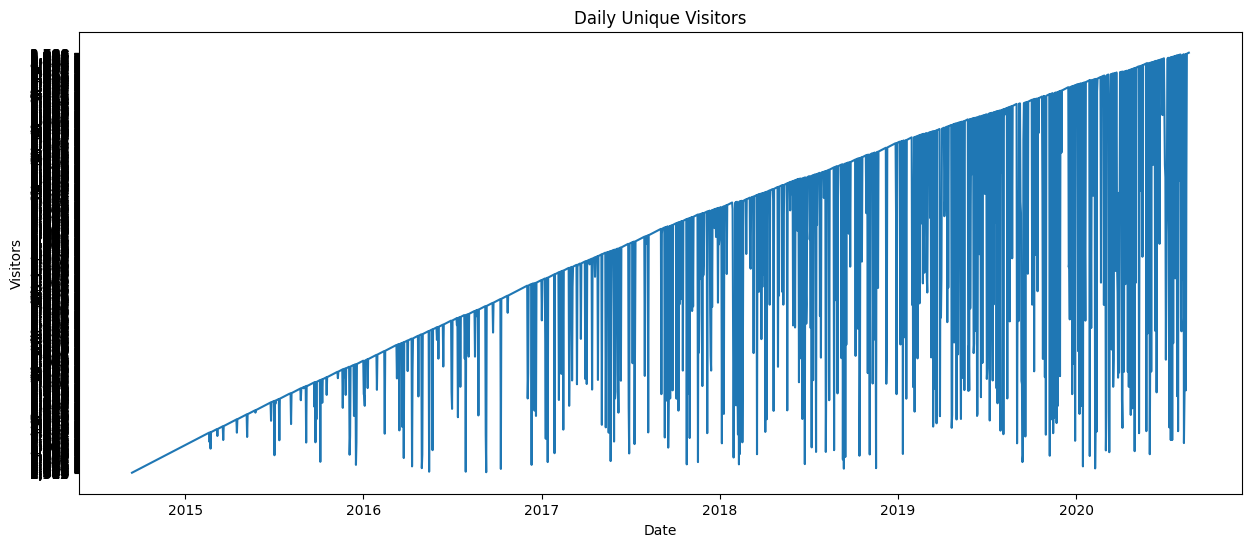

In [10]:
plt.figure(figsize=(15,6))
plt.plot(data['Date'], data['Unique.Visits'])
plt.title("Daily Unique Visitors")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.show()

# Normalize Data

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Clean the 'Unique.Visits' column by removing commas and converting to numeric
data.loc[:, 'Unique.Visits'] = data['Unique.Visits'].str.replace(',', '').astype(float)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Unique.Visits']])

# Create Sequences

In [15]:
import numpy as np

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2137, 30, 1)
(2137, 1)


# Train Test Split

In [16]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(1709, 30, 1)
(428, 30, 1)


# Build GRU Model

In [17]:
model = Sequential()
model.add(GRU(64,
              return_sequences=True,
              input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(64))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compile Model

In [18]:
model.compile(optimizer='adam',
              loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0545 - val_loss: 0.0217
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0266 - val_loss: 0.0187
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0213 - val_loss: 0.0144
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0129 - val_loss: 0.0088
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0088 - val_loss: 0.0071
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - val_loss: 0.0065
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0044 - val_loss: 0.0034
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - val_loss: 0.0033
Epoch 9/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 10/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 11/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0024 - val_loss: 0.0030
Epoch 12/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - val_

# Plot Training Loss

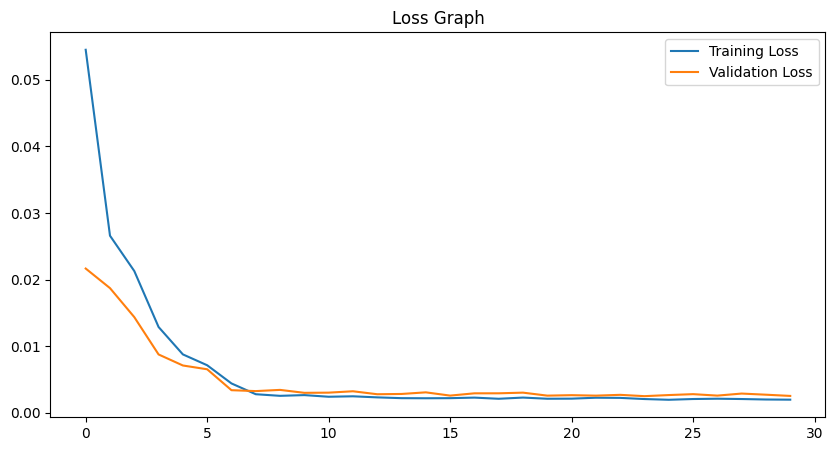

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Loss Graph")
plt.show()

# Prediction

In [28]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [29]:
last_30_days = scaled_data[-sequence_length:]

last_30_days = last_30_days.reshape(1, sequence_length, 1)

next_day = model.predict(last_30_days)

next_day = scaler.inverse_transform(next_day)

print("Predicted Next Day Visitors:", next_day[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Next Day Visitors: 1599.4576


# Plot Actual VS Predicted

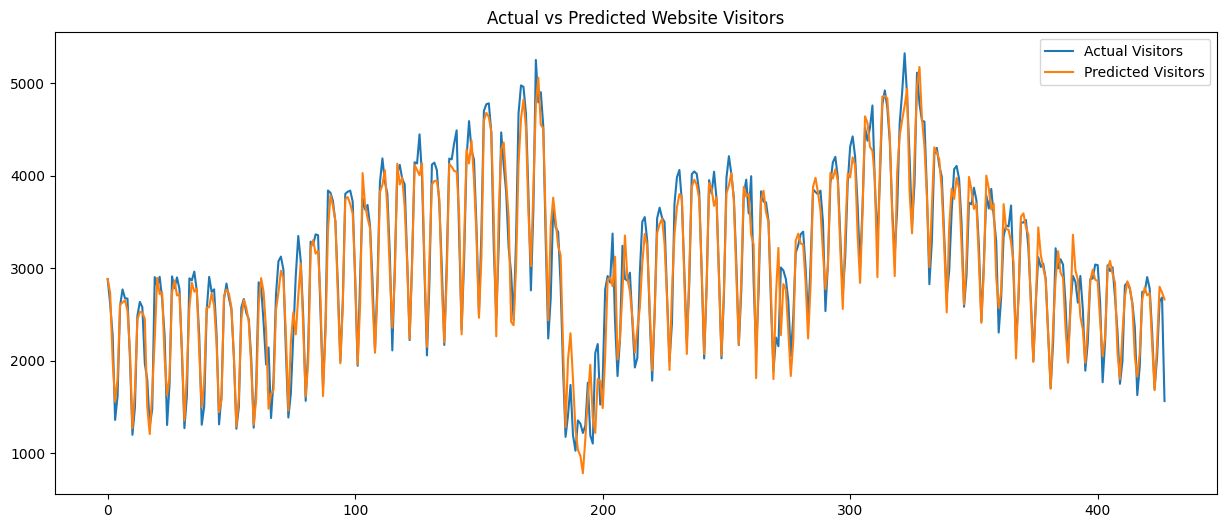

In [30]:
plt.figure(figsize=(15,6))

plt.plot(actual, label='Actual Visitors')
plt.plot(predictions, label='Predicted Visitors')

plt.legend()
plt.title("Actual vs Predicted Website Visitors")
plt.show()